# Building a K-Nearest Neighbours Classifier

CSI 4106 — Introduction to Artificial Intelligence

Marcel Turcotte  
2026-09-13

# Introduction

This notebook develops a small k-nearest neighbours (KNN) classifier
from first principles. KNN illustrates an approach to learning that is
very different from constructing a decision tree or estimating the
coefficients of a linear model. Its central idea can be summarized in
three words:

> **Store, search, vote.**

Learning consists of storing the training examples. When a prediction is
requested, the classifier finds nearby examples and lets them vote. The
implementation supports multiclass labels and both uniform and
distance-weighted voting.

# Preparation

The installation step runs only if `palmerpenguins` is unavailable,
making the notebook suitable for a fresh Google Colab session.

In [2]:
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np

try:
    from palmerpenguins import load_penguins
except ImportError:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "palmerpenguins"
    ])
    from palmerpenguins import load_penguins

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Palmer Penguins

We retain bill length and bill depth and classify all three penguin
species. These two features produce a useful example: the classes are
distinguishable, but not perfectly separable, so changing the
neighbourhood changes the decision boundary.

In [3]:
feature_names = ["bill_length_mm", "bill_depth_mm"]

penguins = load_penguins()
penguins = penguins[feature_names + ["species"]].dropna().copy()

X = penguins[feature_names].to_numpy()
y = penguins["species"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training examples: {len(X_train)}")
print(f"Test examples: {len(X_test)}")
print(f"Classes: {np.unique(y_train)}")

Training examples: 273
Test examples: 69
Classes: ['Adelie' 'Chinstrap' 'Gentoo']

# Feature Scaling

Euclidean distance depends on numerical scale. We therefore standardize
each feature using the training-set mean and standard deviation:

$$
z=\frac{x-\mu_{\mathrm{train}}}{\sigma_{\mathrm{train}}}.
$$

The scaler is fitted only on the training data. The test data must not
influence preprocessing choices made during learning.

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Searching for Neighbours

For a query $x$ and a training example $x_i$, Euclidean distance is

$$
d(x,x_i)=\sqrt{\sum_{j=1}^{D}\left(x^{(j)}-x_i^{(j)}\right)^2}.
$$

The most direct implementation computes every distance, sorts them, and
keeps the first $k$ indices.

In [5]:
def nearest_neighbors(X_train, x, n_neighbors):
    """Return the nearest training indices and their distances from x."""
    distances = np.sqrt(np.sum((X_train - x) ** 2, axis=1))
    indices = np.argsort(distances, kind="stable")[:n_neighbors]
    return indices, distances[indices]

The stable sort makes the result deterministic when two training
examples are equally distant. Production implementations can avoid a
complete sort or use specialized search structures.

# Voting

With uniform voting, all selected neighbours receive weight 1. With
distance weighting, neighbour $i$ receives weight

$$
w_i=\frac{1}{d_i}.
$$

An exact match requires special handling because $1/0$ is undefined. If
exact matches exist, our implementation lets only those observations
vote.

In [6]:
def voting_weights(distances, mode):
    """Return uniform weights or inverse-distance weights."""
    if mode == "uniform":
        return np.ones(len(distances))

    exact_matches = distances == 0
    if np.any(exact_matches):
        return exact_matches.astype(float)

    return 1 / distances


def vote_probabilities(labels, weights, classes):
    """Convert the neighbours' weighted votes into probabilities."""
    scores = np.array([
        np.sum(weights[labels == label])
        for label in classes
    ])
    return scores / np.sum(scores)

# Classifier

The `fit` method stores the training set. Most of the work occurs in
`_predict_proba_one`: find the neighbours, assign their voting weights,
and aggregate votes by class.

Validation is included so that unsupported inputs produce clear errors,
but it is not part of the central KNN idea.

In [7]:
class SimpleKNeighborsClassifier:
    """A didactic classifier with a small scikit-learn-like interface."""

    def __init__(self, n_neighbors=5, weights="uniform"):
        self.n_neighbors = n_neighbors
        self.weights = weights

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self._validate_training_data(X, y)

        self.X_train_ = X.copy()
        self.y_train_ = y.copy()
        self.classes_ = np.unique(y)
        self.n_features_in_ = X.shape[1]
        return self

    def _predict_proba_one(self, x):
        indices, distances = nearest_neighbors(
            self.X_train_, x, self.n_neighbors
        )
        labels = self.y_train_[indices]
        weights = voting_weights(distances, self.weights)
        return vote_probabilities(labels, weights, self.classes_)

    def predict_proba(self, X):
        X = self._validate_prediction_data(X)
        return np.vstack([self._predict_proba_one(x) for x in X])

    def predict(self, X):
        probabilities = self.predict_proba(X)
        return self.classes_[np.argmax(probabilities, axis=1)]

    def score(self, X, y):
        return float(np.mean(self.predict(X) == np.asarray(y)))

    def _validate_training_data(self, X, y):
        if X.ndim != 2 or y.ndim != 1 or len(X) != len(y):
            raise ValueError(
                "X must be 2-D and y must be 1-D with matching rows"
            )
        if len(y) == 0:
            raise ValueError("the training set cannot be empty")
        if not np.isfinite(X).all():
            raise ValueError(
                "missing and non-finite feature values are unsupported"
            )
        if not isinstance(self.n_neighbors, (int, np.integer)):
            raise ValueError("n_neighbors must be an integer")
        if not 1 <= self.n_neighbors <= len(y):
            raise ValueError("n_neighbors must be between 1 and len(y)")
        if self.weights not in {"uniform", "distance"}:
            raise ValueError("weights must be 'uniform' or 'distance'")

    def _validate_prediction_data(self, X):
        if not hasattr(self, "X_train_"):
            raise ValueError("call fit before making predictions")
        X = np.asarray(X, dtype=float)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        if X.ndim != 2 or X.shape[1] != self.n_features_in_:
            raise ValueError("X has the wrong number of features")
        if not np.isfinite(X).all():
            raise ValueError(
                "missing and non-finite feature values are unsupported"
            )
        return X

# Training and Evaluation

The two models below use the same five neighbours. Only their voting
rule changes.

In [8]:
for mode in ("uniform", "distance"):
    knn = SimpleKNeighborsClassifier(n_neighbors=5, weights=mode)
    knn.fit(X_train_scaled, y_train)
    accuracy = knn.score(X_test_scaled, y_test)
    print(f"k=5, weights='{mode}': accuracy={accuracy:.3f}")

k=5, weights='uniform': accuracy=0.957
k=5, weights='distance': accuracy=0.957

## Inspecting one prediction

Because KNN bases a prediction directly on stored examples, we can
inspect the neighbourhood responsible for an individual result.

In [9]:
query = X_test_scaled[0]
indices, distances = nearest_neighbors(X_train_scaled, query, n_neighbors=5)

print(f"True class: {y_test[0]}")
print(f"Predicted class: {knn.predict(query)[0]}")
print("\nNeighbours:")
for rank, (index, distance) in enumerate(zip(indices, distances), start=1):
    print(f"{rank}: {y_train[index]:9s} distance={distance:.3f}")

True class: Adelie
Predicted class: Adelie

Neighbours:
1: Adelie    distance=0.018
2: Adelie    distance=0.053
3: Adelie    distance=0.088
4: Adelie    distance=0.100
5: Adelie    distance=0.128

# Decision Boundaries

The custom classifier is sufficient for prediction, but plotting four
dense grids would distract from its essential logic. The following
visualization therefore uses scikit-learn’s optimized
`KNeighborsClassifier` and `DecisionBoundaryDisplay`.

A pipeline standardizes the features internally, allowing the axes to
remain in their original units.

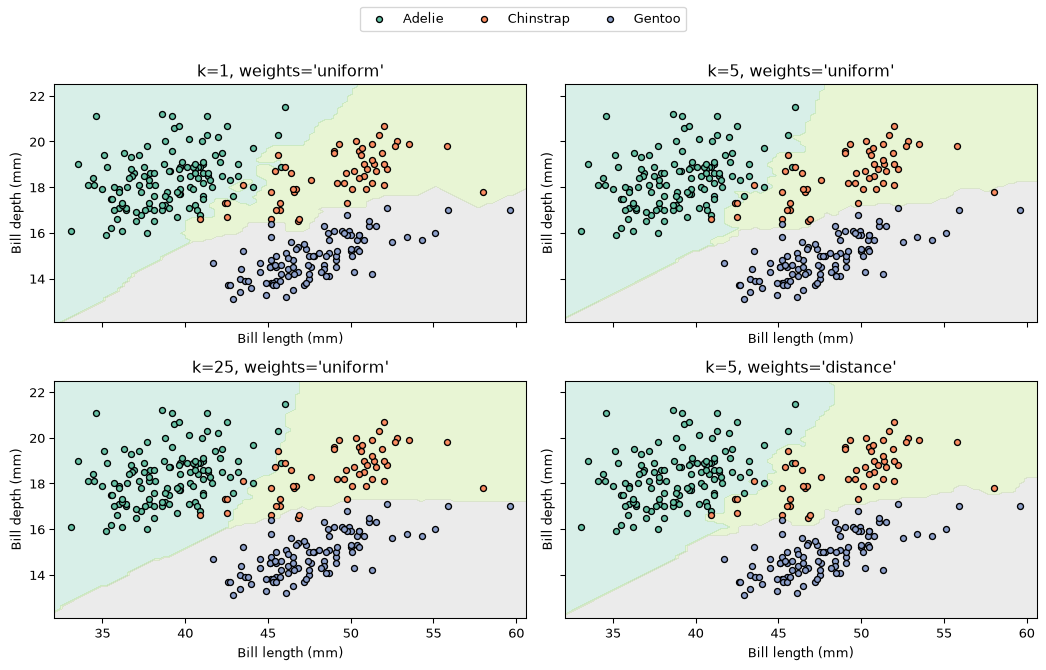

In [10]:
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline

configurations = [
    (1, "uniform"),
    (5, "uniform"),
    (25, "uniform"),
    (5, "distance"),
]
classes, y_encoded = np.unique(y_train, return_inverse=True)

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True)
for ax, (n_neighbors, weights) in zip(axes.ravel(), configurations):
    sklearn_knn = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights),
    )
    sklearn_knn.fit(X_train, y_encoded)
    DecisionBoundaryDisplay.from_estimator(
        sklearn_knn,
        X_train,
        response_method="predict",
        multiclass_colors="Set2",
        alpha=0.25,
        ax=ax,
    )

    for label, name in enumerate(classes):
        selected = y_encoded == label
        ax.scatter(
            X_train[selected, 0],
            X_train[selected, 1],
            color=plt.get_cmap("Set2")(label),
            edgecolor="black",
            s=20,
            label=name,
        )

    ax.set_title(f"k={n_neighbors}, weights='{weights}'")
    ax.set_xlabel("Bill length (mm)")
    ax.set_ylabel("Bill depth (mm)")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncols=len(classes))
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

With $k=1$, individual training observations control small regions,
producing a highly irregular boundary. Increasing $k$ smooths the
boundary because a larger neighbourhood must agree. Distance weighting
allows nearby observations to retain greater local influence.

# Regression

The neighbour search does not change for regression. We replace the
class vote with a weighted average of numerical targets:

In [11]:
def regression_prediction(targets, distances, mode="uniform"):
    weights = voting_weights(distances, mode)
    return float(np.average(targets, weights=weights))

Since the result is an average of observed neighbour targets, ordinary
KNN regression does not extrapolate beyond their range.

# Complexity and Limitations

For each query, this straightforward implementation computes distances
in $\mathcal{O}(ND)$ and performs a complete $\mathcal{O}(N\log N)$
sort. It also retains the $\mathcal{O}(ND)$ training set in memory.

Other important limitations include:

- distances are sensitive to feature scaling and the selected metric;
- neighbourhoods become less informative in high-dimensional spaces;
- small $k$ can be sensitive to noise, whereas large $k$ can hide local
  structure; and
- class imbalance can dominate a neighbourhood’s vote.

# Suggested Experiments

1.  Compare test accuracy for several values of `n_neighbors`.
2.  Change the four configurations in the decision-boundary figure.
3.  Remove standardization and observe how the results change.
4.  Replace Euclidean distance with Manhattan distance.
5.  Create a query equal to a training example and inspect distance
    weighting.
6.  Compare this implementation with scikit-learn’s
    `KNeighborsClassifier`.